In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd


# Open the NetCDF file
file_path = "/lustre/storeB/users/maltem/sflux.arome_arctic_det_2_5km_20240417T00Z.nc"
ds = xr.open_dataset(file_path)

# Define target latitude and longitude
target_lat = 80.6
target_lon = 12.0

# Find the nearest grid point
latitudes = ds["latitude"]
longitudes = ds["longitude"]

# Compute distances to the target point
distance = np.sqrt((latitudes - target_lat)**2 + (longitudes - target_lon)**2)
min_index = np.unravel_index(np.argmin(distance.values), distance.shape)

# Extract the flux data for the nearest point
flux_accumulated = ds["integral_of_surface_downwelling_shortwave_flux_in_air_wrt_time"][:, 0, min_index[0], min_index[1]].values
time = ds["time"].values

# Deaccumulate the flux
flux_deaccumulated = np.diff(flux_accumulated, prepend=np.nan)  # Prepend NaN to align array size
time_readable = [pd.Timestamp(t).to_pydatetime() for t in time]


/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


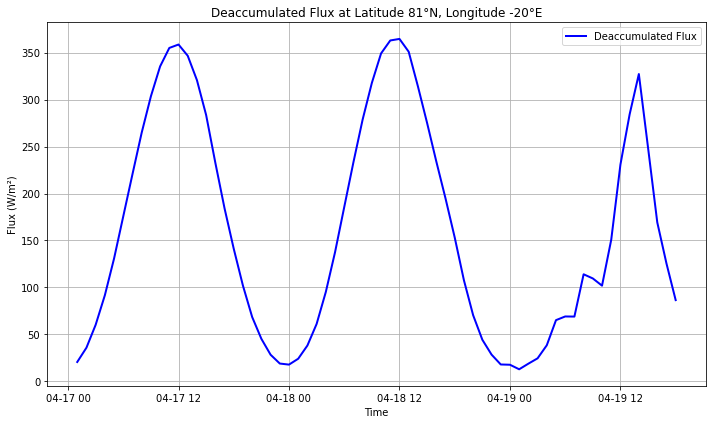

In [2]:
import pandas as pd  # Ensure pandas is imported

# Convert time to readable format
time_readable = [pd.Timestamp(t).to_pydatetime() for t in time]

# Plot the deaccumulated flux
plt.figure(figsize=(10, 6))
plt.plot(time_readable, flux_deaccumulated/3600, label="Deaccumulated Flux", color="blue", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Flux (W/m²)")
plt.title("Deaccumulated Flux at Latitude 81°N, Longitude -20°E")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#ds['ssdr'] = x['integral_of_surface_downwelling_shortwave_flux_in_air_wrt_time'].isel(height0=0, x=slice(*x_bnds), y=slice(*y_bnds)).reset_coords('height0', drop=True).diff(dim='time') / 3600

In [3]:
var = 'integral_of_surface_downwelling_shortwave_flux_in_air_wrt_time'

In [ ]:
flux = ds[var].isel(height0=0, y=min_index[0], x=min_index[1]).reset_coords('height0', drop=True).diff(dim='time') / 3600

In [ ]:
plt.plot(flux)